In [ ]:
import matplotlib.pyplot as plt
import pathlib, os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras


from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dropout , GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint

C:\Users\coder\new_anaconda\anaconda3\envs\cpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
#!pip3 install matplotlib
#!pip install pytz

In [ ]:
data_dir = pathlib.Path( "C:\\recent caltech\\journal 1\\indian bird dataset\\test\\")
BirdClasses = np.array(([item.name for item in data_dir.glob("*")]))
print(BirdClasses)

['Babblers bird' 'Barbets bird' 'Bulbuls bird' 'Coots bird' 'Cranes bird'
 'Cuckoos bird' 'Doves bird' 'Drongos bird' 'Ducks bird' 'Eagles bird'
 'Egrets bird' 'Falcons bird' 'Finches bird' 'Flycatchers bird'
 'Herons bird' 'Hornbills bird' 'Jacanas bird' 'Kingfishers bird'
 'Munias bird' 'Nightjars bird' 'Orioles bird' 'Owls bird'
 'Parakeets bird' 'Peafowl bird' 'Pheasants bird' 'Pigeons bird'
 'Plovers bird' 'Prinias bird' 'Robins bird' 'Sandpipers bird'
 'Shrikes bird' 'Storks bird' 'Sunbirds bird' 'Swallows bird'
 'Swamphens bird' 'Swifts bird' 'Terns bird' 'Tits bird' 'Wagtails bird'
 'Warblers bird' 'Woodpeckers bird']


In [ ]:
#Model.save("70_30_best_result_non_Segmented_Xception.h5")
new_model1= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\xception.h5")
new_model2= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\inception.h5")
new_model3= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mobilenet.h5")
new_model4= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\resnet.h5")
new_model5= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\VGG.h5")
new_model6= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\VGG16.h5")
new_model7= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\effecientnetv2final.h5")
#new_model8= tf.keras.models.load_model("transformer1.h5")
# Show the model architecture
new_model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 7, 7, 2048)        20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization_4 (Batc  (None, 2048)             8192      
 hNormalization)                                                 
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization_5 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                        

In [ ]:
from transformers import TFViTModel
import tensorflow as tf

new_model8 = tf.keras.models.load_model(
    "C:\\recent caltech\\journal 1\\indian bird dataset\\final transformer\\transformer1.h5",
    custom_objects={"TFViTModel": TFViTModel}
)
"""
new_model8.compile(optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, decay=1e-6, momentum=0.9, nesterov=True),
               loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
"""
initial_lr = 0.01
decay_rate = 0.96
decay_steps = 1000

def lr_scheduler(epoch):
    return initial_lr * (decay_rate ** (epoch // decay_steps))

new_model8.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\coder\new_anaconda\anaconda3\envs\cpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
"""
from vit_keras import vit
import tensorflow_addons as tfa


image_size = 224
batch_size = 32
n_classes = 20
EPOCHS = 5


vit_model = vit.vit_b16(
        weights = "imagenet21k",
        image_size = image_size,
        activation = 'softmax',
        pretrained = True,
        include_top = False,
        pretrained_top = False,
        classes = 200)

import tensorflow.keras.layers as L

class Patches(L.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images = images,
            sizes = [1, self.patch_size, self.patch_size, 1],
            strides = [1, self.patch_size, self.patch_size, 1],
            rates = [1, 1, 1, 1],
            padding = 'VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

model8 = tf.keras.Sequential([
        vit_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(256, activation = tfa.activations.gelu),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(256, activation = tfa.activations.gelu),
        tf.keras.layers.Dense(256, activation = tfa.activations.gelu),
        tf.keras.layers.Dense(200, 'softmax')
    ],
    name = 'vision_transformer')

model8.summary()

model8= tf.keras.models.load_model("only_transformer.h5")
"""

'\nfrom vit_keras import vit\nimport tensorflow_addons as tfa \n\n\nimage_size = 224\nbatch_size = 32\nn_classes = 20\nEPOCHS = 5\n\n\nvit_model = vit.vit_b16(\n        weights = "imagenet21k",\n        image_size = image_size,\n        activation = \'softmax\',\n        pretrained = True,\n        include_top = False,\n        pretrained_top = False,\n        classes = 200)\n\nimport tensorflow.keras.layers as L\n\nclass Patches(L.Layer):\n    def __init__(self, patch_size):\n        super(Patches, self).__init__()\n        self.patch_size = patch_size\n\n    def call(self, images):\n        batch_size = tf.shape(images)[0]\n        patches = tf.image.extract_patches(\n            images = images,\n            sizes = [1, self.patch_size, self.patch_size, 1],\n            strides = [1, self.patch_size, self.patch_size, 1],\n            rates = [1, 1, 1, 1],\n            padding = \'VALID\',\n        )\n        patch_dims = patches.shape[-1]\n        patches = tf.reshape(patches, [batc

In [ ]:
"""
import tensorflow as tf
from tensorflow.keras.layers import Input, Lambda, Dense
from tensorflow.keras.models import Model
from transformers import TFViTModel


vit_model = TFViTModel.from_pretrained("google/vit-base-patch16-224",from_pt=True )

# Define input with shape (224, 224, 3)
input_layer = Input(shape=(224, 224, 3), name='input_image')

# Transpose to channels_first
transposed = Lambda(lambda x: tf.transpose(x, perm=[0, 3, 1, 2]))(input_layer)

# Pass through the ViT model
vit_outputs = vit_model(pixel_values=transposed, training=False)

# Extract the [CLS] token
cls_token = vit_outputs.last_hidden_state[:, 0, :]  # Shape: (batch_size, hidden_size)

# Add custom classification layers
x = Dense(1024, activation='relu')(cls_token)
x = Dense(512, activation='relu')(x)
output = Dense(200, activation='softmax')(x)  # Adjust the number of classes as needed

# Define the final model
new_model8 = Model(inputs=input_layer, outputs=output)

new_model8= tf.keras.models.load_model("C:\\recent caltech\\caltech full\\not segmented\\90 5 5\\transformer\\transformer1.h5")
"""

'\nimport tensorflow as tf\nfrom tensorflow.keras.layers import Input, Lambda, Dense\nfrom tensorflow.keras.models import Model\nfrom transformers import TFViTModel\n\n\nvit_model = TFViTModel.from_pretrained("google/vit-base-patch16-224",from_pt=True )\n\n# Define input with shape (224, 224, 3)\ninput_layer = Input(shape=(224, 224, 3), name=\'input_image\')\n\n# Transpose to channels_first\ntransposed = Lambda(lambda x: tf.transpose(x, perm=[0, 3, 1, 2]))(input_layer)\n\n# Pass through the ViT model\nvit_outputs = vit_model(pixel_values=transposed, training=False)\n\n# Extract the [CLS] token\ncls_token = vit_outputs.last_hidden_state[:, 0, :]  # Shape: (batch_size, hidden_size)\n\n# Add custom classification layers\nx = Dense(1024, activation=\'relu\')(cls_token)\nx = Dense(512, activation=\'relu\')(x)\noutput = Dense(200, activation=\'softmax\')(x)  # Adjust the number of classes as needed\n\n# Define the final model\nnew_model8 = Model(inputs=input_layer, outputs=output)\n\nnew_mod

In [ ]:
#import torch

#x = torch.rand(5, 3)
#print(x)
#print(torch.__version__)
#print(torch.cuda.is_available())

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir= "C:\\recent caltech\\journal 1\\indian bird dataset\\test\\"
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )
filenames = test_data.filenames
nb_samples = len(filenames)

prediction1 = new_model1.predict(test_data ,steps = nb_samples)

prediction2 = new_model2.predict(test_data ,steps = nb_samples)

prediction3 = new_model3.predict(test_data ,steps = nb_samples)

prediction4 = new_model4.predict(test_data ,steps = nb_samples)

prediction5 = new_model5.predict(test_data ,steps = nb_samples)

prediction6 = new_model6.predict(test_data ,steps = nb_samples)

prediction7 = new_model7.predict(test_data ,steps = nb_samples)

prediction8 = new_model8.predict(test_data ,steps = nb_samples)


Found 321 images belonging to 41 classes.
200/321 [=================>............] - ETA: 18s 

C:\Users\coder\new_anaconda\anaconda3\envs\cpu\lib\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


321/321 [==============================] - 174s 520ms/step


In [ ]:
y_prediction=[]
print(prediction1)
import numpy as np
y_prediction.append(prediction1)
y_prediction.append(prediction2)
y_prediction.append(prediction3)
y_prediction.append(prediction4)
y_prediction.append(prediction5)
y_prediction.append(prediction6)
y_prediction.append(prediction7)
y_prediction.append(prediction8)

array1=np.array(y_prediction)
array1.shape

[[9.9971277e-01 5.6597912e-07 2.3992793e-06 ... 8.5697387e-09
  2.1327788e-08 1.3169458e-07]
 [8.7556887e-01 4.7810563e-06 1.1283321e-04 ... 6.2243576e-04
  1.2693095e-02 2.2539216e-05]
 [2.5026813e-02 9.5942471e-04 1.2340940e-03 ... 9.4743085e-04
  4.1829783e-04 6.5527926e-04]
 ...
 [1.0882807e-03 1.9020712e-02 5.3011812e-03 ... 9.1378206e-05
  3.6898362e-03 9.4000465e-01]
 [6.9436648e-12 1.2126708e-08 7.7466539e-10 ... 4.5504717e-10
  9.2052593e-10 9.9999630e-01]
 [3.5126482e-06 2.4617148e-05 4.1052845e-06 ... 6.2716185e-06
  5.5110722e-06 9.9527609e-01]]


(8, 321, 41)

In [ ]:
import numpy as np
import statistics

def minn(array):
    return min(array)

def maxx(array):
    return(max(array))

def mean(array):
    return statistics.mean(array)

def median(array):
    return statistics.median(array)

def product(array):

    # Multiply elements one by one
    result = 1
    for x in array:
        result = result * x
    return result

def majority(arr):
    m = {}
    for i in range(len(arr)):
        if arr[i] in m:
            m[arr[i]] += 1
        else:
            m[arr[i]] = 1
    #print(m)
    maxx=0
    for i in m:
        #print(i, m[i])
        if maxx<m[i]:
            maxx=m[i]
    for i in m:
        if m[i]==maxx:
            break
    return i









#in this piece of code we will create array of features for different combination
array2=array1
#print(array2)
array2.shape
l2=[]
l1=[]
l3=[]
for i11 in range(len(array2[0])):
    l2=[]
    for i1 in range(len(array2[0][0])):
        l1=[]
        for i in range(len(array2)):
            l1.append(array2[i][i11][i1])
        l2.append(l1)
    l3.append(l2)
print(l3)





[[[0.99971277, 0.798815, 0.9998783, 0.9983259, 0.901365, 0.4096234, 0.999998, 0.99964976], [5.659791e-07, 0.0010878983, 2.4709277e-06, 2.9481674e-07, 1.886858e-06, 0.0019584475, 5.3305726e-10, 3.1403292e-06], [2.3992793e-06, 0.00049048045, 6.752242e-07, 1.0421868e-05, 4.7492977e-05, 0.03489047, 4.8803926e-08, 2.1291464e-05], [1.00708455e-08, 0.00017231118, 8.748915e-09, 1.30056615e-05, 0.00012784151, 0.00016045274, 2.5769395e-10, 3.5189225e-07], [1.9190994e-08, 5.0320028e-05, 3.7176042e-09, 3.299347e-08, 1.483525e-06, 0.0002151582, 7.5700307e-10, 6.788246e-07], [1.0238375e-05, 0.117490664, 9.808362e-05, 0.00029563764, 0.0032306637, 0.05856228, 1.1613139e-06, 1.6215969e-06], [1.7327237e-08, 0.0004950442, 3.83086e-06, 1.5119289e-06, 1.698653e-05, 0.04579219, 2.748025e-09, 2.7123274e-06], [8.314199e-07, 0.0030572873, 2.2045033e-07, 0.0001986476, 0.0017565534, 0.12923813, 4.002391e-08, 1.6754461e-06], [6.9743315e-08, 4.1263364e-05, 6.624537e-10, 7.981591e-08, 9.468247e-07, 1.136982e-05, 3.

In [ ]:
import numpy
from sklearn.metrics import accuracy_score



l33=np.array(l3)
#print(l33.shape)

# min as the combination procedure
a1=[]
for i in range(len(l33)):
    a2=[]
    for i1 in range(len(l33[0])):
        a2.append(minn(l33[i][i1]))
    a1.append(a2)

print(len(a1))
minn_vector=numpy.argmax(a1, axis=1)
print(minn_vector)
print(accuracy_score(test_data.classes, minn_vector))
print("min")
# max as the combination procedure
a1=[]
for i in range(len(l33)):
    a2=[]
    for i1 in range(len(l33[0])):
        a2.append(maxx(l33[i][i1]))
    a1.append(a2)

print(len(a1))
maxx_vector=numpy.argmax(a1, axis=1)
print(maxx_vector)
print(accuracy_score(test_data.classes, maxx_vector))
print("max")
# mean as the combination procedure
a1=[]
for i in range(len(l33)):
    a2=[]
    for i1 in range(len(l33[0])):
        a2.append(mean(l33[i][i1]))
    a1.append(a2)

print(len(a1))
mean_vector=numpy.argmax(a1, axis=1)
print(mean_vector)
print(accuracy_score(test_data.classes, mean_vector))
print("mean")
# median as the combination procedure
a1=[]
for i in range(len(l33)):
    a2=[]
    for i1 in range(len(l33[0])):
        a2.append(median(l33[i][i1]))
    a1.append(a2)

print(len(a1))
median_vector=numpy.argmax(a1, axis=1)
print(median_vector)
print(accuracy_score(test_data.classes, median_vector))
print("median")
# product as the combination procedure
a1=[]
for i in range(len(l33)):
    a2=[]
    for i1 in range(len(l33[0])):
        a2.append(product(l33[i][i1]))
    a1.append(a2)

print(len(a1))
product_vector=numpy.argmax(a1, axis=1)
print(product_vector)
print(accuracy_score(test_data.classes, product_vector))
print("product")
# majority as the combination procedure
a1=[]
for i in range(len(l33)):
    a2=[]
    for i1 in range(len(l33[0])):
        a2.append(majority(l33[i][i1]))
    a1.append(a2)

print(len(a1))
majority_vector=numpy.argmax(a1, axis=1)
print(majority_vector)
print(accuracy_score(test_data.classes, majority_vector))
print("majority")


321
[ 0  0  7  0  0  0  0  2  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  3
  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4  5  5  5  5  9  5  5  0  6
  6  6  6  6  6  6  6  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8 21
  9  9  9  9  9  9  9 10 10 10 10 10 10 10 10 11  9 11 11 11 11 11 11 12
 11 12 12 12 12 12 12  4  7 13 27 32 13 39 13 14 14 14 10 14 14 14 14 15
 16 15 15 15 15 15 15 16 34 16 16 16 16 16 16 17 17 17 17 17 17 17 17  0
 27 18 18 18 27 18 38 19 19 19 19 19  7 19 19 20  0 20 20 20 20 22 20 21
 21 21 21 21 21 21 21 22 22 22 23 22 22 22 22 23 23 23 23 23 23 23 23 24
 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 26 26 26 26 26 26 26 26 27
 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28 29 29 29 29 29 29 29 29 30
 27 30 30 30 30 30  0 31 31 37 31 31 31 31 31 32 32 32 32 32 32 32 32 33
 33 27 37 35 33 33 33 34 34 34 34 34 34 34 34 35 35 35 36 36 36 36 36 36
 36 36 37 39 37 39 37 37 37 38 38 38 38 38 38 38 38 39 39 39 39 39 39 39
 39 40 40 40 40 40 40 40 40]
0.9034267912772586

In [ ]:
#!pip install scikit-learn

In [ ]:
import math
import random
import matplotlib.pyplot as plt


def function1(predicted, y_test):
    x=0
    for i in range(len(predicted)):
        if predicted[i]!=y_test[i]:
            x=x+1
    return( x/len(predicted))


def subfunction(c1,c2, predicted):
    n00,n11,n10,n01=0,0,0,0
    for i in range(len(predicted)):
        if c1[i]==predicted[i] and c2[i]==predicted[i]:
            n11=n11+1
        elif  c1[i]!=predicted[i] and c2[i]==predicted[i]:
            n01=n01+1
        elif  c1[i]==predicted[i] and c2[i]!=predicted[i]:
            n10=n10+1
        elif  c1[i]!=predicted[i] and c2[i]!=predicted[i]:
            n00=n00+1
    value=(n11*n00)-(n01*n10)/((n11*n00)+(n10*n01))
    return value

def function2(P):
    val=0
    L=len(P)
    for i in range(0,L-2):
        for j in range(i,L):
            val=val+subfunction(P[i],P[j],y_test)

    value=(val*2)/((L+1)*(L))
    return value




def binaryToDecimal(n):

    num = n;
    dec_value = 0;

    # Initializing base
    # value to 1, i.e 2 ^ 0
    base = 1;

    temp = num;
    while(temp):
        last_digit = temp % 10;
        temp = int(temp / 10);

        dec_value += last_digit * base;
        base = base * 2;
    return dec_value;

def random_chromozome_generate(p):

  while(True):
      key1 = ""
      for i in range(p):


          temp = str(random.randint(0, 1))


          key1 += temp
      if (binaryToDecimal(int(key1[8:11]))<=5)and (binaryToDecimal(int(key1[8:11]))>0):
            break

  return key1

def mutate(x):
  #print(x)

  x=list(x)


  while(True):
    x1=random.randrange(len(x))
    x=list(x)
    if x[x1]=="0":
      x[x1]="1"
    else:
      x[x1]="0"
    x=''.join(x)
    if binaryToDecimal(int(x[8:11]))<6:
      break
  #x[0]=xy
  return x





def swap(x,y):
  temp = x
  x = y
  y = temp
  return x,y





def crossover(x1,x2):

  while(True):
    xy1=list(x1)
    xy2=list(x2)
    pt1=random.randrange(len(x1))
    for i in range(pt1,len(x1)):
      xy1[i],xy2[i]=swap(xy1[i],xy2[i])
    xy1=''.join(xy1)
    xy2=''.join(xy2)
    p=len(x1)
    if binaryToDecimal(int(xy1[8:11]))<6 and  binaryToDecimal(int(xy2[8:11]))<6 :
      break
  #x1[0]=xy1
  #x2[0]=xy2
  return xy1,xy2






def disect(x,array1):
    p=[]
    #print(x)
    arr=[]
    x=''.join(x)
    for i in range(0,8):
        if x[i]=='1':
            p.append(array1[i])
    #print(x)
    x1= binaryToDecimal(int(x[8:11]))
    #print(x1)
    #print(x1)
    l2=[]
    l1=[]
    l3=[]
    null_vector=[]
    #print(len(p[0]))
    for i in range(len(array1[0])):
        null_vector.append(-1)




    if len(p)==0:
            return null_vector,[]
    #print(p)
    #print(p[0])
    for i12 in range(len(p[0])):

        l2=[]
        for i1 in range(len(p[0][0])):
            l1=[]
            for i in range(len(p)):
                l1.append(p[i][i12][i1])
            l2.append(l1)
        l3.append(l2)
    #print(l3)



    if x1==0:
        #print("Vote")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(majority(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        majority_vector=numpy.argmax(a1, axis=1)
        #print(majority_vector)
        #print(accuracy_score(y_test, majority_vector))
        return majority_vector, p

    elif x1==1:
        #print("max")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(minn(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        min_vector=numpy.argmax(a1, axis=1)
        #print( min_vector)
        #print(accuracy_score(y_test, min_vector))
        return min_vector, p
    elif x1==2:
        #print("min")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(maxx(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        maxx_vector=numpy.argmax(a1, axis=1)
        #print(maxx_vector)
        #print(accuracy_score(y_test, maxx_vector))
        return maxx_vector, p
    elif x1==3:
        #print("mean")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(mean(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        mean_vector=numpy.argmax(a1, axis=1)
        #print(mean_vector)
        #print(accuracy_score(y_test, mean_vector))
        return mean_vector, p
    elif x1==4:
        #print("median")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(median(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        median_vector=numpy.argmax(a1, axis=1)
        #print(median_vector)
        #print(accuracy_score(y_test, median_vector))
        return median_vector, p
    elif x1==5:
        #print("product")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(product(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        product_vector=numpy.argmax(a1, axis=1)
        #print(product_vector)
        #print(accuracy_score(y_test, product_vector))
        return product_vector, p

    else:
        print("invalid")

# the below code is implementation of the NSGA2
#-------------------------------------------------
#------------------------------------------
#initalise the nasga parameters
pop_size = 20
#max_gen = 921
#generate random population of N chromozomes
chromozome=[]
for i in range(pop_size):
  ch=random_chromozome_generate(11)
  #ch=listtostring(ch)
  chromozome.append(ch)

chromozome.append("11111111000")
chromozome.append("11111111001")
chromozome.append("11111111010")
chromozome.append("11111111011")
chromozome.append("11111111100")
chromozome.append("11111111101")

print(chromozome)
#evalate the objectives of the popluation

fun1=[]
fun2=[]
obj_one=[]

for i in chromozome:
  x=[]
  vector,p=disect(i, array1)
  #p1=numpy.argmax(p,axis=2)
  fun1.append(function1(vector,test_data.classes))
  x.append(i)
  x.append(accuracy_score(vector,test_data.classes))
  obj_one.append(x)

"""
  if p==[]:
        fun2.append(1)
  else:
        fun2.append(function2(numpy.argmax(p, axis=2)))
"""
  #print(p)
  #print(vector)
#print(fun1)
#print(fun2)
print(obj_one)
#perform the first two steps i.e.

#non dominated sorting

#crowding distance

#loop
#-----------------------------------------------
#binary tornament selection

#crossover

#mutation

#evaluate the obectives of the offspring

#combine the current popluation and the offspring population

#non dominated sorting

#crowding distancnce

#sorting base on fronts and crowding distance

#select the first N chromozomes as new population of the next genaration

#-------------------------------------------------

#return the perito optimal solutions as soltions of the final output

['10111100101', '00000101101', '10010010001', '01000011010', '11010011100', '11101001100', '11000000010', '11001001001', '01000000100', '11111100001', '10010100101', '01110101100', '11000000010', '10011001001', '01100001100', '10100011001', '10001111100', '00100000011', '10101110100', '11010010001', '11111111000', '11111111001', '11111111010', '11111111011', '11111111100', '11111111101']
[['10111100101', 0.8878504672897196], ['00000101101', 0.9314641744548287], ['10010010001', 0.9158878504672897], ['01000011010', 0.956386292834891], ['11010011100', 0.9376947040498442], ['11101001100', 0.9034267912772586], ['11000000010', 0.8847352024922118], ['11001001001', 0.9283489096573209], ['01000000100', 0.778816199376947], ['11111100001', 0.8722741433021807], ['10010100101', 0.8940809968847352], ['01110101100', 0.9065420560747663], ['11000000010', 0.8847352024922118], ['10011001001', 0.9252336448598131], ['01100001100', 0.897196261682243], ['10100011001', 0.9283489096573209], ['10001111100', 0.9

In [ ]:
sorted(obj_one,key=lambda l:l[1], reverse=True)

[['01000011010', 0.956386292834891],
 ['11010011100', 0.9376947040498442],
 ['10001111100', 0.9376947040498442],
 ['11111111011', 0.9376947040498442],
 ['11111111101', 0.9345794392523364],
 ['00000101101', 0.9314641744548287],
 ['11111111010', 0.9314641744548287],
 ['11001001001', 0.9283489096573209],
 ['10100011001', 0.9283489096573209],
 ['10011001001', 0.9252336448598131],
 ['11111111100', 0.9190031152647975],
 ['10010010001', 0.9158878504672897],
 ['01110101100', 0.9065420560747663],
 ['10101110100', 0.9065420560747663],
 ['11010010001', 0.9065420560747663],
 ['11101001100', 0.9034267912772586],
 ['11111111001', 0.9034267912772586],
 ['01100001100', 0.897196261682243],
 ['10010100101', 0.8940809968847352],
 ['11111111000', 0.8909657320872274],
 ['10111100101', 0.8878504672897196],
 ['11000000010', 0.8847352024922118],
 ['11000000010', 0.8847352024922118],
 ['11111100001', 0.8722741433021807],
 ['00100000011', 0.794392523364486],
 ['01000000100', 0.778816199376947]]

In [ ]:
a={}
for i in obj_one:
    a[i[0]]=i[1]


In [ ]:
import random
def tournament4(obj_one):
  num1= random.choice(obj_one)
  #print(num1[1])
  num2= random.choice(obj_one)
  #print(num2[1])
  num3= random.choice(obj_one)
  #print(num3[1])
  num4= random.choice(obj_one)
  #print(num4[1])
  if num1[1]>num2[1]:
    num5=num1
  else:
    num5=num2
  if num3[1]>num4[1]:
    num6=num3
  else:
    num6=num4
  if num5[1]>num6[1]:
    num7=num5
  else:
    num7=num6
  return num7


def tournament2(obj_one):
  num1= random.choice(obj_one)
  #print(num1[1])
  num2= random.choice(obj_one)
  #print(num2[1])

  if num1[1]>num2[1]:
    num5=num1[0]
  else:
    num5=num2[0]

  return num5

In [ ]:

                            max_gen = 20
pop_size = 20
max_gen1 =20
pop_size1 = 20


while(max_gen1):
  pop_size1 = 20
  max_gen1=max_gen1-1
  while(pop_size1):
    val1=[]
    val2=[]
    #print(max_gen1, pop_size1)
    pop_size1=pop_size1-1
    pi1=tournament2(obj_one)
    pi2=tournament2(obj_one)
    p=random.uniform(0, 1)
    #print(p1,p2)
    #print(pi1, pi2)
    if p>0.5:
      p11=mutate(pi1)
      p21=mutate(pi2)
    else:
      p11,p21=crossover(pi1,pi2)
    vector,p=disect(p11, array1)
    #print(vector)
    p1=accuracy_score(vector,test_data.classes)
    vector,p=disect(p21, array1)
    p2=accuracy_score(vector,test_data.classes)
    val1.append(p11)
    val1.append(p1)
    val2.append(p21)
    val2.append(p2)
    #print(val1)
    #print(val2)
    obj_one.append(val1)
    obj_one.append(val2)
    a[p11]=p1
    a[p21]=p2
  #print(len(obj_one))
  #print(obj_one)
  #a[p11]=p1
  #a[p21]=p2
  obj_one=sorted(obj_one,key=lambda l:l[1], reverse=True)

  obj_one=obj_one[:30]
  print(obj_one)
  #obj_one=obj_one[:pop_size]
  #print(obj_one)





[['01000011010', 0.956386292834891], ['10010011100', 0.9501557632398754], ['10010011101', 0.9470404984423676], ['01010011010', 0.9470404984423676], ['10010011101', 0.9470404984423676], ['10100111101', 0.9439252336448598], ['10010011001', 0.9439252336448598], ['10111111011', 0.940809968847352], ['01000001010', 0.940809968847352], ['11010011100', 0.9376947040498442], ['10001111100', 0.9376947040498442], ['11111111011', 0.9376947040498442], ['10010001001', 0.9376947040498442], ['10010001001', 0.9376947040498442], ['11111111101', 0.9345794392523364], ['01100011100', 0.9345794392523364], ['11111011010', 0.9345794392523364], ['00110011100', 0.9345794392523364], ['00000101101', 0.9314641744548287], ['11111111010', 0.9314641744548287], ['00111111101', 0.9314641744548287], ['11001001001', 0.9283489096573209], ['10100011001', 0.9283489096573209], ['10011001001', 0.9252336448598131], ['10011001001', 0.9252336448598131], ['10010010101', 0.9252336448598131], ['10011001001', 0.9252336448598131], ['1

In [ ]:
print(obj_one)

[['00000011100', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011100', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011100', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011100', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011100', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011100', 0.9657320872274143], ['00000011100', 0.9657320872274143], ['00000111011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011011', 0.9657320872274143], ['00000011100', 0.9657320872274143], 

In [ ]:
b=sorted(a,key=lambda l:l[1], reverse=True)
print(a)

{'10111100101': 0.8878504672897196, '00000101101': 0.9314641744548287, '10010010001': 0.9158878504672897, '01000011010': 0.956386292834891, '11010011100': 0.9376947040498442, '11101001100': 0.9034267912772586, '11000000010': 0.8847352024922118, '11001001001': 0.9283489096573209, '01000000100': 0.778816199376947, '11111100001': 0.8722741433021807, '10010100101': 0.8940809968847352, '01110101100': 0.9065420560747663, '10011001001': 0.9252336448598131, '01100001100': 0.897196261682243, '10100011001': 0.9283489096573209, '10001111100': 0.9376947040498442, '00100000011': 0.794392523364486, '10101110100': 0.9065420560747663, '11010010001': 0.9065420560747663, '11111111000': 0.8909657320872274, '11111111001': 0.9034267912772586, '11111111010': 0.9314641744548287, '11111111011': 0.9376947040498442, '11111111100': 0.9190031152647975, '11111111101': 0.9345794392523364, '01100011100': 0.9345794392523364, '10010010101': 0.9252336448598131, '00111111100': 0.9127725856697819, '11100000011': 0.884735

In [ ]:
print(b)

['01000011010', '11010011100', '11101001100', '11000000010', '11001001001', '01000000100', '11111100001', '01110101100', '01100001100', '11010010001', '11111111000', '11111111001', '11111111010', '11111111011', '11111111100', '11111111101', '01100011100', '11100000011', '01010010100', '11111011001', '01100010101', '11010011000', '01010011010', '01000001010', '11111011010', '01000001000', '11011111100', '01110011100', '11000000011', '11110111010', '01010011100', '01000111010', '01000010010', '11100111101', '11000111010', '01010011101', '01011001001', '01010011011', '01100111010', '01000111011', '01010111011', '01000101010', '01010011000', '01011011010', '01010010101', '01000001011', '01000011101', '01000011100', '11010111101', '01000011011', '01000000010', '11000101101', '01011011101', '01010111100', '01100100100', '11001011100', '10111100101', '00000101101', '10010010001', '10010100101', '10011001001', '10100011001', '10001111100', '00100000011', '10101110100', '10010010101', '00111111

In [ ]:
vector,p=disect('00000011100', array2)

In [ ]:
#!pip install seaborn

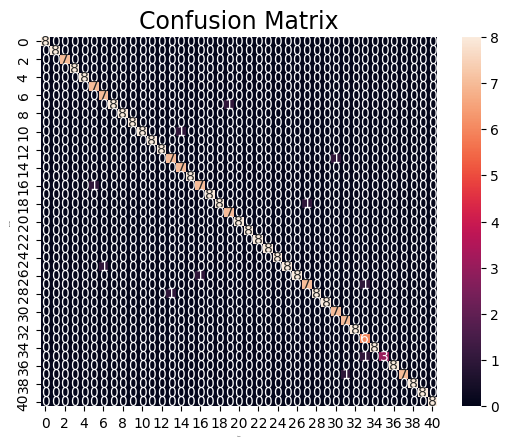

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(vector,test_data.classes)
sns.heatmap(cm, annot=True,fmt='g')
plt.ylabel('Prediction',fontsize=1)
plt.xlabel('Actual',fontsize=1)
plt.title('Confusion Matrix',fontsize=17)
plt.show()


In [ ]:
my_dict =a
# Sort the dictionary by value in ascending order
sorted_dict = dict(sorted(my_dict.items(), key=lambda item: item[1]))

print(sorted_dict)

{'00000100101': 0.6822429906542056, '00000100011': 0.6822429906542056, '01000000100': 0.778816199376947, '01000001000': 0.778816199376947, '01010011000': 0.778816199376947, '01000000010': 0.778816199376947, '00100000011': 0.794392523364486, '00100011000': 0.794392523364486, '00100100100': 0.8006230529595015, '01100100100': 0.8411214953271028, '11111100001': 0.8722741433021807, '10010100001': 0.8722741433021807, '10001000101': 0.8785046728971962, '10101000101': 0.881619937694704, '11000000010': 0.8847352024922118, '11100000011': 0.8847352024922118, '11000000011': 0.8847352024922118, '10111100101': 0.8878504672897196, '11111111000': 0.8909657320872274, '11010011000': 0.8909657320872274, '10010011000': 0.8909657320872274, '10100011000': 0.8909657320872274, '10010100101': 0.8940809968847352, '01100001100': 0.897196261682243, '01100010101': 0.897196261682243, '00000110011': 0.897196261682243, '11101001100': 0.9034267912772586, '11111111001': 0.9034267912772586, '00010010101': 0.903426791277